# NYISO Solar Forecasting: Physics-Informed Feature Engineering

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from solar_forecast.config import (
    MERGED_OUT,
    MODEL_READY_OUT,
    FIGURES_ROOT,
    TS_COL   as ts_col,
    ZONE_COL as zone_col,
    TARGET   as target,
)

from solar_forecast.features import (
    add_cyclic_features,
    add_regime_flags,
    add_interact_features,
    add_rolling_features,
    FINAL_FEATURES,
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")

## Data Load and Schema Standardization

In [3]:
df = pd.read_csv(MERGED_OUT, low_memory=False)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df[ts_col] = pd.to_datetime(df[ts_col], utc=True, errors="coerce")

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    same_ts_mask = (df["time"] == df[ts_col]) | (df["time"].isna() & df[ts_col].isna())  # was same_time_mask
    if bool(same_ts_mask.all()):
        df = df.drop(columns=["time"])

numeric_cols = [
    "actual_mw",
    "forecast_mw",
    "capacity_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df[zone_col] = df[zone_col].astype(str).str.strip().str.upper()

## Target Definition and Time Context

In [4]:
df["time_local"] = df["time_stamp"].dt.tz_convert("America/New_York")
df["date_local"] = df["time_local"].dt.date
df["year_from_ts"] = df["time_local"].dt.year
df["month_local"] = df["time_local"].dt.month
df["dayofweek_local"] = df["time_local"].dt.dayofweek
df["hour_local"] = df["time_local"].dt.hour

df["is_weekend"] = df["dayofweek_local"].isin([5, 6]).astype(int)
df["is_daylight_proxy"] = (df["shortwave_radiation"] > 0).astype(int)

In [5]:
df["forecast_error_mw"] = df["actual_mw"] - df["forecast_mw"]
df["absolute_error_mw"] = (df["actual_mw"] - df["forecast_mw"]).abs()
df["smape"] = np.where(
    (df["actual_mw"].abs() + df["forecast_mw"].abs()) > 0,
    200 * df["absolute_error_mw"] / (df["actual_mw"].abs() + df["forecast_mw"].abs()),
    np.nan
)

## System-Level Modeling Table

In [6]:
df_system = (
    df[df["zone_name"] == "SYSTEM"]
    .copy()
    .sort_values("time_stamp")
    .reset_index(drop=True)
)

print("System Shape:", df_system.shape)
print("System Time Range:", df_system["time_stamp"].min(), "to", df_system["time_stamp"].max())

System Shape: (42451, 22)
System Time Range: 2020-11-17 00:00:00+00:00 to 2025-09-20 23:00:00+00:00


## Physics-Informed Feature Construction

### Cyclic Solar-Time Features
solar gen is periodic with 24 hours and 365 days, sin(theta) = sin((2*pi*t)/T)
sin/cos encoding: sin(2*pi*t/T), cos(2*pi*t/T) preserves circular continuity

In [7]:
df_system["dayofyear_local"] = df_system["time_local"].dt.dayofyear

df_system["hour_sin"] = np.sin(2 * np.pi * df_system["hour_local"] / 24)
df_system["hour_cos"] = np.cos(2 * np.pi * df_system["hour_local"] / 24)

df_system["month_sin"] = np.sin(2 * np.pi * df_system["month_local"] / 12)
df_system["month_cos"] = np.cos(2 * np.pi * df_system["month_local"] / 12)

df_system["dayofyear_sin"] = np.sin(2 * np.pi * df_system["dayofyear_local"] / 365.25)
df_system["dayofyear_cos"] = np.cos(2 * np.pi * df_system["dayofyear_local"] / 365.25)

### Solar Regime Features

In [8]:
df_system["is_morning_ramp"] = df_system["hour_local"].between(6, 9).astype(int)
df_system["is_midday"] = df_system["hour_local"].between(10, 14).astype(int)

## Capacity Handling
capacity ratio is forecast/installed cap

In [9]:
if "capacity_mw" in df_system.columns:
    df_system["capacity_missing_flag"] = df_system["capacity_mw"].isna().astype(int)

## Weather and Forecast Interaction Features
PV depends on irradiance, temp, and how clouds move
P= f(G,T,C)

PV output P = eta * A * G where G is irradiance (W/m²).

In [10]:
interact_feats = pd.DataFrame(index=df_system.index)

interact_feats["forecast_x_hour_sin"] = df_system["forecast_mw"] * df_system["hour_sin"]
interact_feats["forecast_x_hour_cos"] = df_system["forecast_mw"] * df_system["hour_cos"]
interact_feats["shortwave_x_cloud"]   = df_system["shortwave_radiation"] * (df_system["cloud_cover"] / 100.0)
interact_feats["shortwave_x_temp"]    = df_system["shortwave_radiation"] * df_system["temperature_2m"]

df_system = pd.concat([df_system, interact_feats], axis=1)

### Rolling Windows and Change Features

In [11]:
roll_feats = {
    "forecast_roll_mean_3":   df_system["forecast_mw"].shift(1).rolling(3,  min_periods=1).mean(),
    "shortwave_roll_mean_3":  df_system["shortwave_radiation"].shift(1).rolling(3,  min_periods=1).mean(),
    "forecast_roll_mean_24":  df_system["forecast_mw"].shift(1).rolling(24, min_periods=1).mean(),
    "shortwave_roll_mean_24": df_system["shortwave_radiation"].shift(1).rolling(24, min_periods=1).mean(),
}

df_system = pd.concat([df_system, pd.DataFrame(roll_feats)], axis=1)

df_system["forecast_diff_1"]    = df_system["forecast_mw"].diff(1)
df_system["shortwave_diff_1"]   = df_system["shortwave_radiation"].diff(1)
df_system["shortwave_ramp_abs"] = df_system["shortwave_diff_1"].abs()

## Data Quality and Missingness Diagnostics

In [12]:
feat_missing = (
    pd.DataFrame({
        "column":        df_system.columns,
        "dtype":         [str(df_system[c].dtype) for c in df_system.columns],
        "missing_count": [df_system[c].isna().sum() for c in df_system.columns],
    })
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df_system))
    .sort_values(["missing_count", "column"], ascending=[False, True])
)

feat_missing.head(50)

,column,dtype,missing_count,missing_pct
21,smape,float64,18906,44.536053
20,absolute_error_mw,float64,1000,2.355657
19,forecast_error_mw,float64,1000,2.355657
2,actual_mw,float64,712,1.677228
40,forecast_diff_1,float64,301,0.709053
3,forecast_mw,float64,288,0.678429
33,forecast_x_hour_cos,float64,288,0.678429
32,forecast_x_hour_sin,float64,288,0.678429
36,forecast_roll_mean_3,float64,265,0.624249
4,capacity_mw,float64,72,0.169607


## Final Feature Set Definition
The target is the residual, the error. Also columns that could cause leakage needs to be dropped.

In [26]:
drop_cols = [
    "actual_mw",
    "absolute_error_mw",
    "smape",
    ts_col,
    "time_local",
    "date_local",
    zone_col,
    target,
    "capacity_mw",
    "year_from_ts",
    "month_local",
    "dayofweek_local",
    "hour_local",
    "is_weekend",
]

final_features = [
    "forecast_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",    
    "forecast_x_hour_sin",
    "forecast_x_hour_cos",
    "shortwave_x_cloud",
    "shortwave_x_temp",
    "forecast_roll_mean_3",
    "shortwave_roll_mean_3",
    "forecast_roll_mean_24",
    "shortwave_roll_mean_24",
    "forecast_diff_1",
    "shortwave_diff_1",
    "shortwave_ramp_abs",
    "is_morning_ramp",
    "is_midday",
]

final_features = [c for c in final_features if c in df_system.columns]

X = df_system[final_features].copy()
y = df_system[target].copy()

print("\nTarget:", target)
print("Features:", len(final_features))
print(final_features)


Target: forecast_error_mw
Features: 25
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


In [27]:
X = df_system[final_features].copy()
y = df_system[target].copy()

In [28]:
print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTop NaN Counts in X:")
print(X.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget NaN Count:", y.isna().sum())
print("\nEvaluation NaN Counts:")
print(df_system[["actual_mw", "forecast_mw", target]].isna().sum())


X Shape: (42451, 25)
y Shape: (42451,)

Top NaN Counts in X:
forecast_diff_1           301
forecast_mw               288
forecast_x_hour_cos       288
forecast_x_hour_sin       288
forecast_roll_mean_3      265
forecast_roll_mean_24      13
shortwave_ramp_abs          1
shortwave_diff_1            1
shortwave_roll_mean_24      1
shortwave_roll_mean_3       1
windspeed_10m               0
shortwave_x_temp            0
is_morning_ramp             0
surface_pressure            0
shortwave_x_cloud           0
dtype: int64

Target NaN Count: 1000

Evaluation NaN Counts:
actual_mw             712
forecast_mw           288
forecast_error_mw    1000
dtype: int64


## Train and Test Split

In [29]:
train_mask = df_system[ts_col] < split_date
test_mask  = df_system[ts_col] >= split_date

train_idx = train_mask & y.notna()
test_idx  = (
    test_mask
    & y.notna()
    & df_system["actual_mw"].notna()
    & df_system["forecast_mw"].notna()
)

X_train = X.loc[train_idx].copy()
X_test  = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test  = y.loc[test_idx].copy()

actual_test = df_system.loc[test_idx, "actual_mw"].copy()
nyiso_test  = df_system.loc[test_idx, "forecast_mw"].copy()

print("Split Date:", split_date)
print("Train Time Rows:", int(train_mask.sum()))
print("Test Time Rows:",  int(test_mask.sum()))

print("\nX_train:", X_train.shape)
print("X_test:",   X_test.shape)
print("y_train:",  y_train.shape)
print("y_test:",   y_test.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
assert actual_test.shape[0] == nyiso_test.shape[0] == y_test.shape[0]

Split Date: 2024-07-01 00:00:00+00:00
Train Time Rows: 31724
Test Time Rows: 10727

X_train: (30922, 25)
X_test: (10529, 25)
y_train: (30922,)
y_test: (10529,)


In [30]:
df_system["dataset_split"] = np.where(df_system[ts_col] < split_date, "train", "test")

## Final Feature Diagnostics

In [31]:
feat_diags = pd.DataFrame({
    "feature":           X_train.columns,
    "dtype":             [str(X_train[c].dtype)           for c in X_train.columns],
    "missing_train":     [int(X_train[c].isna().sum())    for c in X_train.columns],
    "missing_train_pct": [100 * X_train[c].isna().mean()  for c in X_train.columns],
    "nunique_train":     [X_train[c].nunique(dropna=True)  for c in X_train.columns],
    "std_train":         [X_train[c].std(skipna=True)     for c in X_train.columns],
}).sort_values(
    ["missing_train_pct", "nunique_train", "feature"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("Feature Diagnostics")
print(". . .")
print(feat_diags)

Feature Diagnostics
. . .
                   feature    dtype  missing_train  missing_train_pct  nunique_train    std_train
0    forecast_roll_mean_24  float64             11           0.035573          17351   299.247128
1          forecast_diff_1  float64             11           0.035573          17697   225.695488
2     forecast_roll_mean_3  float64             11           0.035573          19766   725.482956
3       shortwave_ramp_abs  float64              1           0.003234            402    67.631844
4         shortwave_diff_1  float64              1           0.003234            712    83.619815
5    shortwave_roll_mean_3  float64              1           0.003234           2638   225.186244
6   shortwave_roll_mean_24  float64              1           0.003234           6783    90.829236
7                is_midday    int64              0           0.000000              2     0.406144
8          is_morning_ramp    int64              0           0.000000              2     0.3

In [32]:
corr_input = X_train.copy()
corr_input = corr_input.fillna(corr_input.median(numeric_only=True))

corr_matrix = corr_input.corr(numeric_only=True).abs()

high_corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val >= 0.98:
            high_corr_pairs.append((cols[i], cols[j], corr_val))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "abs_corr"]
).sort_values("abs_corr", ascending=False)

print("\nHigh-Correlation Pairs (|corr| >= 0.98):")
print(high_corr_pairs_df if len(high_corr_pairs_df) > 0 else "nothing found")


High-Correlation Pairs (|corr| >= 0.98):
nothing found


## Model-Ready Dataset Construction

In [33]:
base_cols = [
    ts_col,
    "time_local",
    zone_col,
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    target,
]

out_cols = []
for c in base_cols + final_features:
    if c not in out_cols:
        out_cols.append(c)

model_ready = df_system.loc[
    y.notna() & df_system["forecast_mw"].notna(),
    out_cols
].copy()

model_ready.to_csv(MODEL_READY_OUT, index=False)
print("Model-Ready Shape:", model_ready.shape)
print("Columns:", model_ready.columns.tolist())
print("Output Path:", MODEL_READY_OUT)

Model-Ready Shape: (41451, 31)
Columns: ['time_stamp', 'time_local', 'zone_name', 'dataset_split', 'actual_mw', 'forecast_mw', 'forecast_error_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']
Output Path: /Users/Sumaitat/Documents/Coding/ML_NYISOSolarForecast/data/processed/04_system_model_ready_data.csv


## Final Diagnostic Plots

In [34]:
recent_win = model_ready.tail(min(24 * 21, len(model_ready))).copy()

missing_plot = (
    feat_diags[["feature", "missing_train_pct"]]
    .sort_values("missing_train_pct", ascending=False)
    .reset_index(drop=True)
)

split_counts = (
    model_ready["dataset_split"]
    .value_counts()
    .rename_axis("dataset_split")
    .reset_index(name="row_count")
)

day_share = (
    model_ready
    .assign(is_daylight=(model_ready["shortwave_radiation"] > 0).astype(int))
    .groupby("dataset_split", as_index=False)["is_daylight"]
    .mean()
)

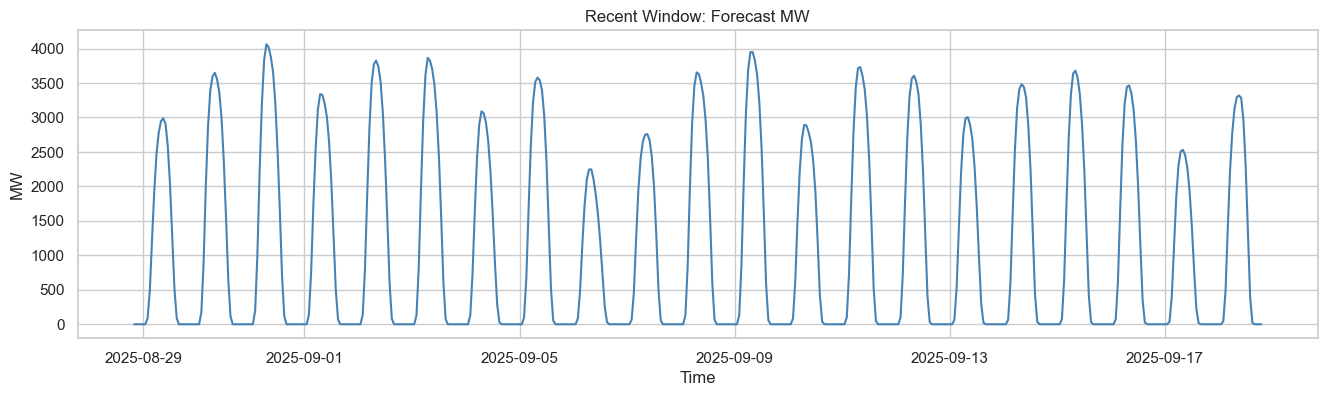

In [35]:
plt.figure(figsize=(16, 4))
sns.lineplot(data=recent_win, x="time_local", y="forecast_mw", color="steelblue")
plt.title("Recent Window: Forecast MW")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()

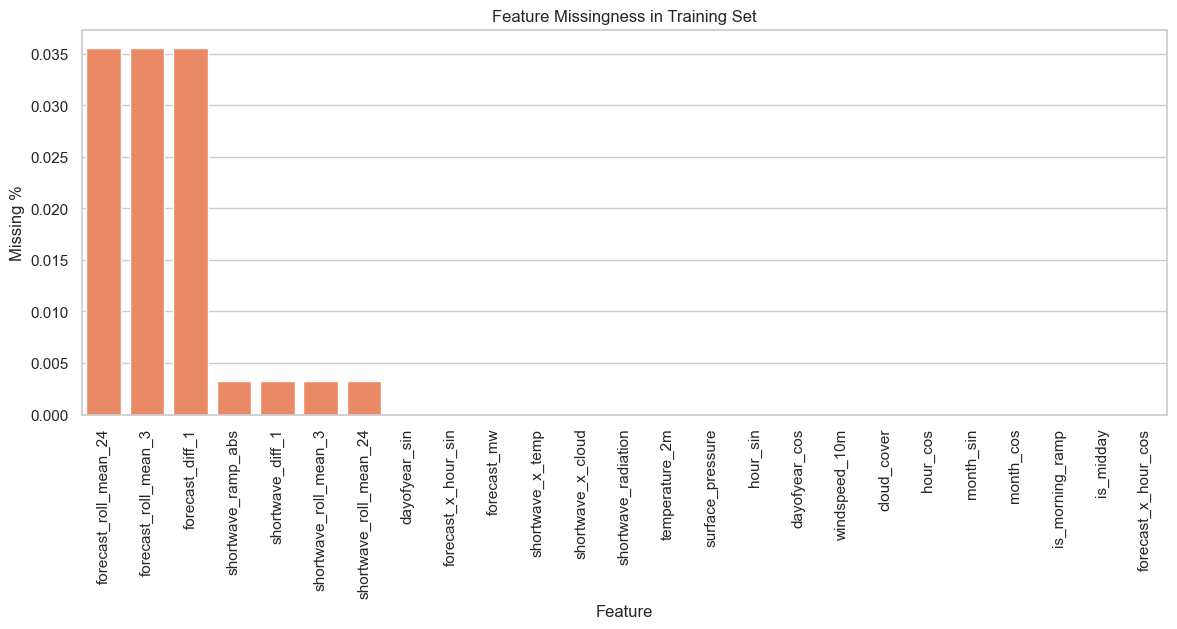

In [36]:
plt.figure(figsize=(14, 5))
sns.barplot(data=missing_plot, x="feature", y="missing_train_pct", color="coral")
plt.title("Feature Missingness in Training Set")
plt.xlabel("Feature")
plt.ylabel("Missing %")
plt.xticks(rotation=90)
plt.show()

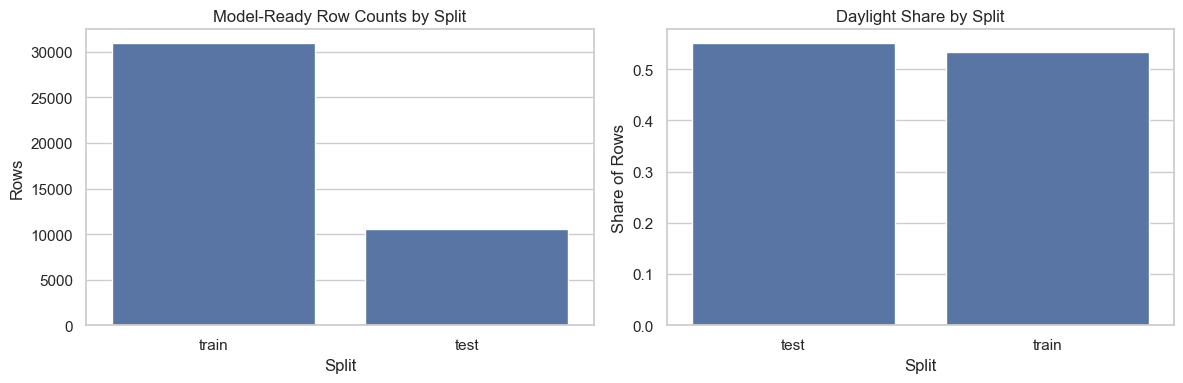

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=split_counts, x="dataset_split", y="row_count", ax=axes[0])
axes[0].set_title("Model-Ready Row Counts by Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Rows")

sns.barplot(data=day_share, x="dataset_split", y="is_daylight", ax=axes[1])
axes[1].set_title("Daylight Share by Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Share of Rows")

plt.tight_layout()
plt.show()

## Findings for the Modeling

## Conclusion and Next Steps

Next we train